In [1]:
import os
import sys
from pathlib import Path
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_NUM_INTRAOP_THREADS"] = "2"
os.environ["TF_NUM_INTEROP_THREADS"] = "2"
os.environ["OMP_NUM_THREADS"] = "2"
project_directory = Path.cwd()
if not (project_directory / "common.py").is_file():
    project_directory = project_directory.parent
sys.path.insert(0, str(project_directory))
from common import ROOT, MODE, SEED, BATCH, EPOCHS, CLASSES, ensure_data, split_paths, seed_all, load_array, evaluate_binary, save_metrics
seed_all()
print(f"Project: {ROOT.name} | mode: {MODE} | seed: {SEED}")


Project: land-classification-github | mode: quick | seed: 7331


In [2]:
import torch
import matplotlib.pyplot as plt
from torch_models import ConvNet, CNNViT, make_loader, fit_model, predict_probabilities
torch.set_num_threads(2)
torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
train, val, test = split_paths()
pretrained_cnn = ConvNet()
pretrained_cnn.load_state_dict(torch.load(ROOT / "models" / "pytorch_cnn.pth", map_location="cpu", weights_only=True))
model = CNNViT(pretrained_cnn)
print("Frozen CNN parameters:", sum(not p.requires_grad for p in model.features.parameters()))
print("Logit shape:", tuple(model(torch.rand(2, 3, 64, 64)).shape))


Frozen CNN parameters: 6
Logit shape: (2, 2)


In [3]:
train_loader = make_loader(*train, augment=True, shuffle=True, batch=BATCH)
val_loader = make_loader(*val, batch=BATCH)
test_loader = make_loader(*test, batch=BATCH)
history = fit_model(model, train_loader, val_loader, epochs=EPOCHS, device=device)
checkpoint = ROOT / "models" / "pytorch_cnn_vit.pth"
torch.save(model.cpu().state_dict(), checkpoint)
metrics = evaluate_binary(test[1], predict_probabilities(model, test_loader, device=device))
print("Test metrics:", {name: value for name, value in metrics.items() if isinstance(value, (float, int))})
print("Saved:", checkpoint.relative_to(ROOT), save_metrics("pytorch_cnn_vit", metrics).relative_to(ROOT))


Epoch 1/2 | train acc 0.875 | val acc 0.861 | val loss 0.330
Epoch 2/2 | train acc 0.884 | val acc 0.875 | val loss 0.333
Test metrics: {'n_test': 72, 'accuracy': 0.8888888888888888, 'precision': 0.9375, 'recall': 0.8333333333333334, 'f1': 0.8823529411764706, 'roc_auc': 0.91820987654321, 'log_loss': 0.2889441997131914}
Saved: models/pytorch_cnn_vit.pth results/pytorch_cnn_vit.json


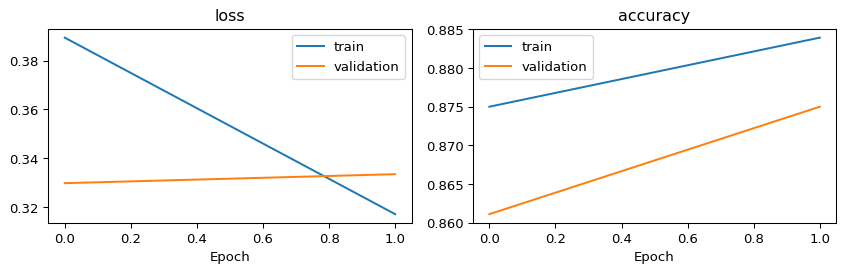

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for axis, metric in zip(axes, ("loss", "accuracy")):
    axis.plot(history[metric], label="train")
    axis.plot(history["val_" + metric], label="validation")
    axis.set(xlabel="Epoch", title=metric)
    axis.legend()
plt.tight_layout()
plt.show()
